Missing Values:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Class Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64


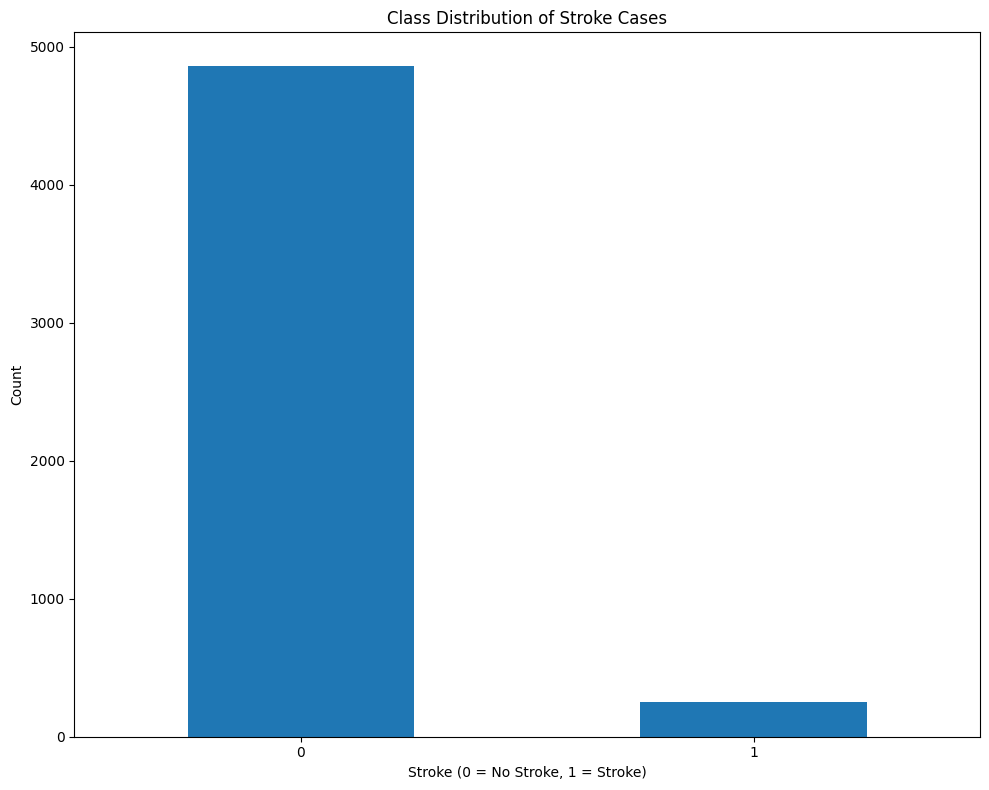

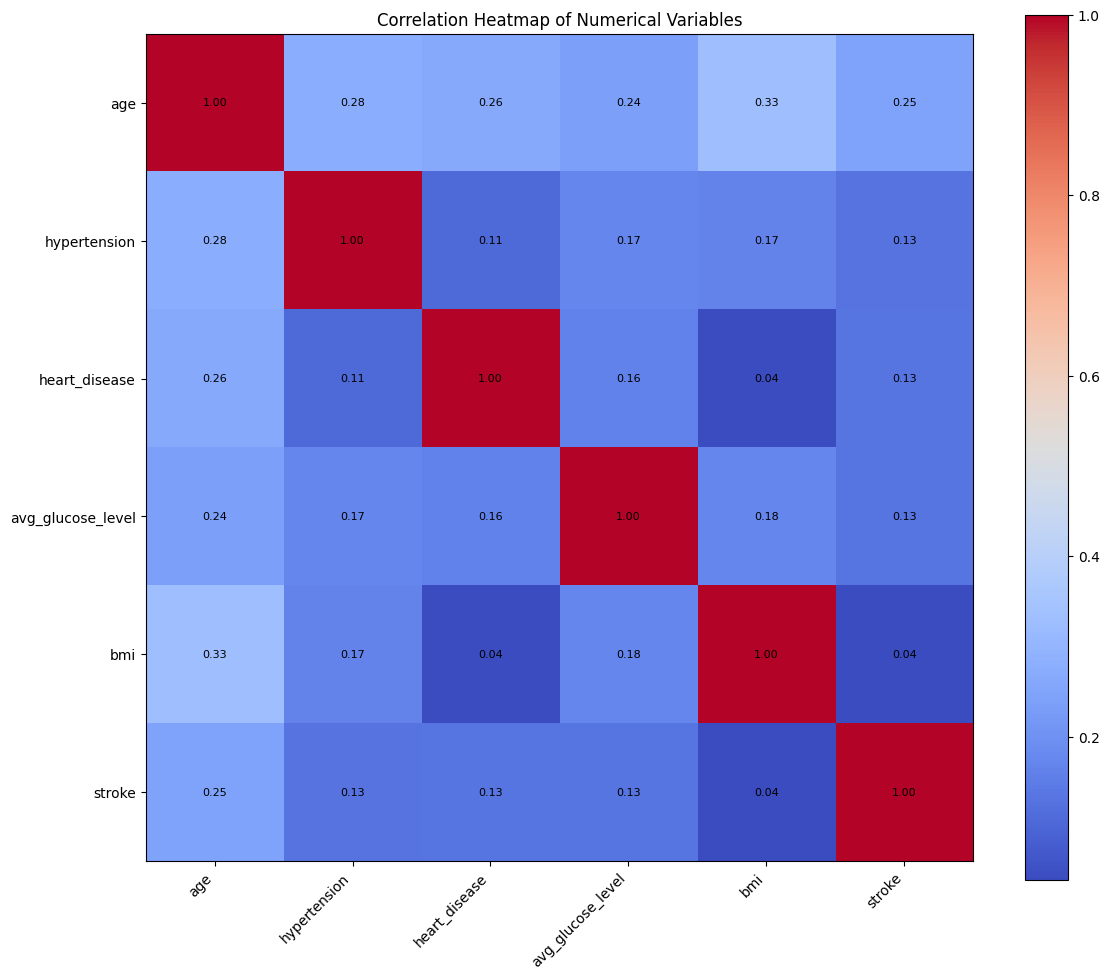


Categorical Variable Categories:
gender: ['Male' 'Female' 'Other']
ever_married: ['Yes' 'No']
work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type: ['Urban' 'Rural']
smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']

Shape after preprocessing and one-hot encoding:
(5110, 21)

Logistic Regression
Before SMOTE:
stroke
0    3889
1     199
Name: count, dtype: int64
After SMOTE:
stroke
0    3889
1    3889
Name: count, dtype: int64

Logistic Regression
----------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.55      1022
weighted avg       0.95      0.75      0.82      1022



<Figure size 1000x800 with 0 Axes>

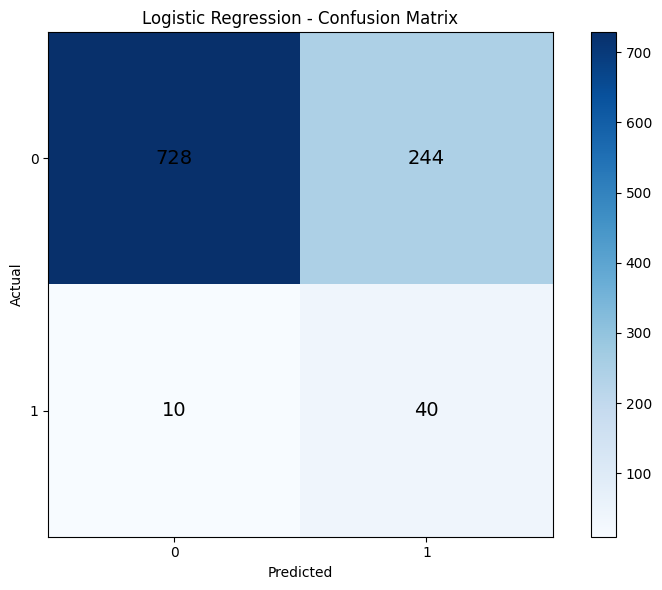


Decision Tree
Before SMOTE:
stroke
0    3889
1     199
Name: count, dtype: int64
After SMOTE:
stroke
0    3889
1    3889
Name: count, dtype: int64

Decision Tree
----------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.76      0.85       972
           1       0.13      0.72      0.22        50

    accuracy                           0.75      1022
   macro avg       0.56      0.74      0.54      1022
weighted avg       0.94      0.75      0.82      1022



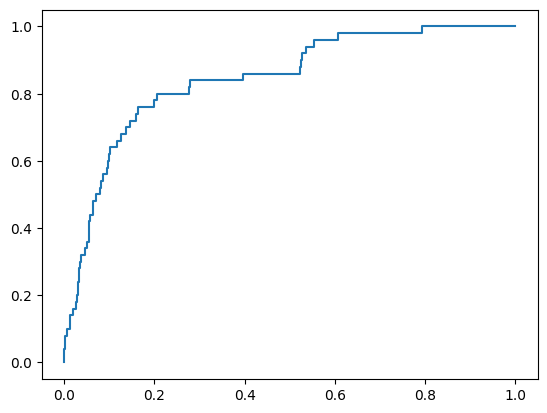

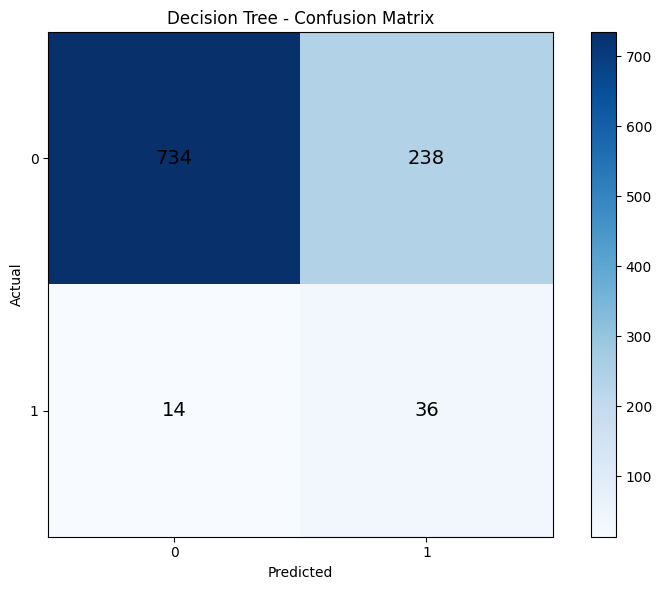


Random Forest
Before SMOTE:
stroke
0    3889
1     199
Name: count, dtype: int64
After SMOTE:
stroke
0    3889
1    3889
Name: count, dtype: int64

Random Forest
----------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       972
           1       0.14      0.10      0.11        50

    accuracy                           0.92      1022
   macro avg       0.54      0.53      0.54      1022
weighted avg       0.91      0.92      0.92      1022



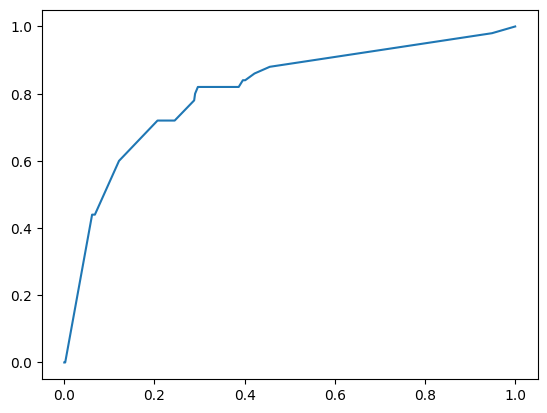

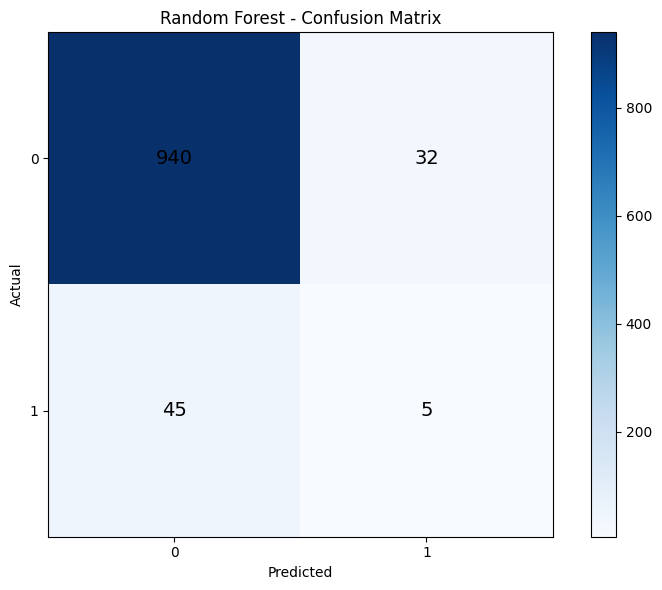

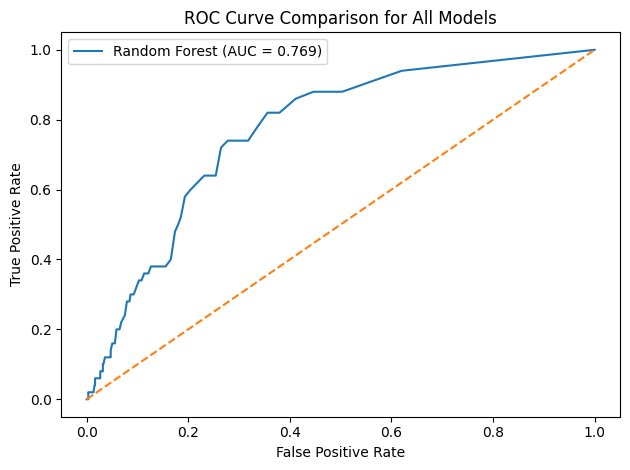


Model Comparison:
                 Model  Accuracy  F1 Score   ROC-AUC
0  Logistic Regression  0.751468  0.239521  0.845226
1        Decision Tree  0.753425  0.222222  0.808961
2        Random Forest  0.924658  0.114943  0.769239


<Figure size 1000x800 with 0 Axes>

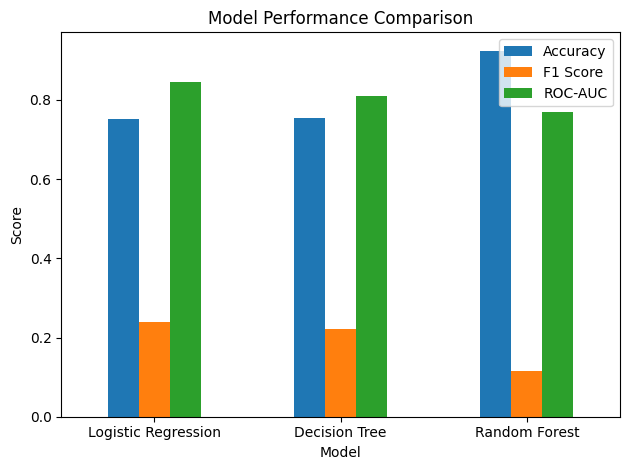

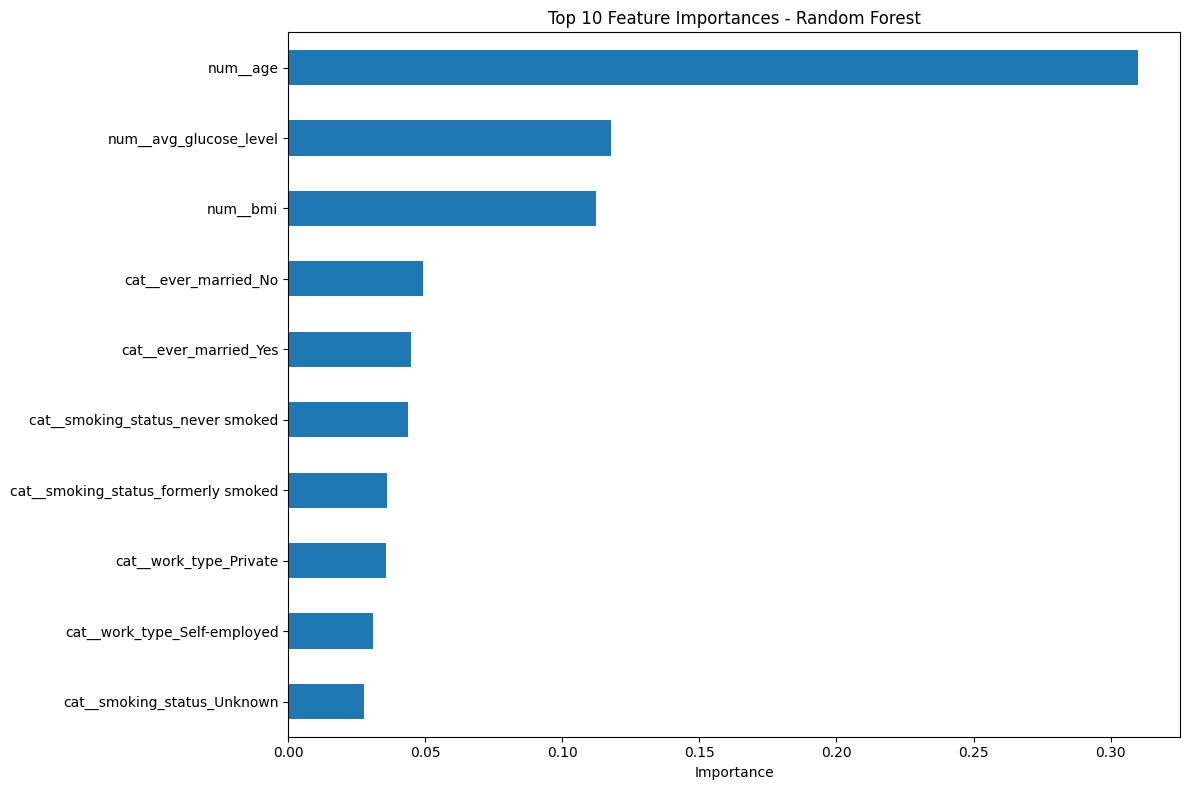

In [4]:
# STROKE PREDICTION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

# CREATE FOLDER FOR PLOTS
os.makedirs("plots", exist_ok=True)

# 1. LOAD DATA
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df = df.drop(columns=["id"])

# PRINT MISSING VALUES
print("Missing Values:")
print(df.isnull().sum())

# PRINT CLASS DISTRIBUTION
print("\nClass Distribution:")
print(df["stroke"].value_counts())

# 2. BASIC VISUALS

# Class distribution
plt.figure(figsize=(10, 8))
df["stroke"].value_counts().plot(kind="bar")
plt.title("Class Distribution of Stroke Cases")
plt.xlabel("Stroke (0 = No Stroke, 1 = Stroke)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plots/class_distribution.png", bbox_inches="tight")
plt.show()

# Correlation heatmap
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Numerical Variables")

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", bbox_inches="tight")
plt.show()

# 3. FEATURES & TARGET
X = df.drop("stroke", axis=1)
y = df["stroke"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# PRINT CATEGORICAL VALUES
print("\nCategorical Variable Categories:")
for col in categorical_features:
    print(f"{col}: {df[col].unique()}")

# 4. PREPROCESSING
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# NUMBER OF FEATURES AFTER ENCODING
X_encoded = preprocessor.fit_transform(X)
print("\nShape after preprocessing and one-hot encoding:")
print(X_encoded.shape)

# 5. SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. MODELS WITH CLASS BALANCING + SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )
}

results = []

# ROC CURVE FIGURE
plt.figure(figsize=(10, 8))

# 7. TRAIN + EVALUATE + VISUALS
for name, model in models.items():

    clf = ImbPipeline([
        ("preprocessing", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
for name, model in models.items():

    clf = ImbPipeline([
        ("preprocessing", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    print(f"\n{name}")
    print("Before SMOTE:")
    print(y_train.value_counts())

    X_temp = preprocessor.fit_transform(X_train)
    X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_temp, y_train)

    print("After SMOTE:")
    print(pd.Series(y_smote).value_counts())

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    results.append([name, acc, f1, roc])

    print(f"\n{name}")
    print("-" * 40)
    print(classification_report(y_test, y_pred))

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    for i in range(len(cm)):
        for j in range(len(cm)):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

    plt.tight_layout()
    plt.savefig(
        f"plots/{name.replace(' ', '_')}_confusion_matrix.png",
        bbox_inches="tight"
    )
    plt.show()

    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc:.3f})")

# FINAL ROC CURVE COMPARISON
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("plots/roc_curve_comparison.png", bbox_inches="tight")
plt.show()

# 8. RESULTS TABLE + BAR CHART
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "F1 Score", "ROC-AUC"]
)

print("\nModel Comparison:")
print(results_df.sort_values(by="ROC-AUC", ascending=False))

# SAVE RESULTS TABLE CSV
results_df.to_csv("plots/model_results.csv", index=False)

# BAR CHART
plt.figure(figsize=(10, 8))
results_df.set_index("Model").plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plots/model_performance.png", bbox_inches="tight")
plt.show()

# 9. FEATURE IMPORTANCE
rf_pipeline = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train, y_train)

encoded_features = rf_pipeline.named_steps["preprocessing"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

feat_imp = pd.Series(importances, index=encoded_features).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
feat_imp.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("plots/feature_importance.png", bbox_inches="tight")
plt.show()